

---

## 🧠 Notebook Goal

**End-to-End Credit Card Fraud Detection**

* EDA → Feature Engineering
* Imbalanced data handling
* Train **multiple ML models**
* Proper evaluation & insights

---



---

## 📑 Table of Contents

1. Introduction
2. Dataset Overview
3. Import Libraries
4. Data Loading
5. Data Cleaning
6. Exploratory Data Analysis (EDA)
7. Feature Engineering
8. Handling Imbalanced Data
9. Data Preprocessing
10. Model Building
11. Model Evaluation
12. Feature Importance
13. Conclusion & Future Work

---

## 🟢 1. Introduction (Notebook Text)

> Credit card fraud is a major challenge in the financial sector. This notebook presents an end-to-end machine learning approach to detect fraudulent transactions using a synthetic dataset of 10,000 credit card records.
>
> The goal is to explore transaction patterns, handle class imbalance, and compare multiple classification models using appropriate evaluation metrics.

---

## 📊 2. Dataset Overview

* Rows: 10,000
* Features: 10
* Target: `is_fraud`
* Imbalanced distribution (~5%)

---

## 📈 3. EDA (High-Quality Visual Ideas)

Use **for-loops** to keep code clean 👇

### Key Plots

* Fraud vs Non-Fraud count
* Amount distribution (hist + KDE)
* Fraud by transaction hour
* Boxplot: Amount vs Fraud
* Correlation heatmap



---

## ⚙️ 4. Feature Engineering

* Amount to risk ratio
* Night transaction flag
* High velocity flag


---

## ⚖️ 5. Handle Imbalanced Data

Explain clearly why accuracy is misleading.

Options:

* Class weight
* SMOTE


---

## 🤖 6. Models to Train (5–8 is perfect)

* Logistic Regression
* Decision Tree
* Random Forest
* XGBoost
* LightGBM
* CatBoost

---

## 📏 7. Evaluation Metrics (Very Important)

Use:

* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix



---

## 📌 8. Feature Importance

(Random Forest / XGBoost)



---

## 🧾 9. Conclusion (Notebook Text)

> This notebook demonstrated how machine learning models can effectively identify fraudulent credit card transactions despite class imbalance. Tree-based models performed particularly well, achieving high recall while minimizing false negatives.

---




In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv("/kaggle/input/credit-card-fraud-detection-dataset/credit_card_fraud_10k.csv")
df.head()


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
# Check missing values
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [4]:
# Remove duplicates if any
df = df.drop_duplicates()

In [5]:

# Check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


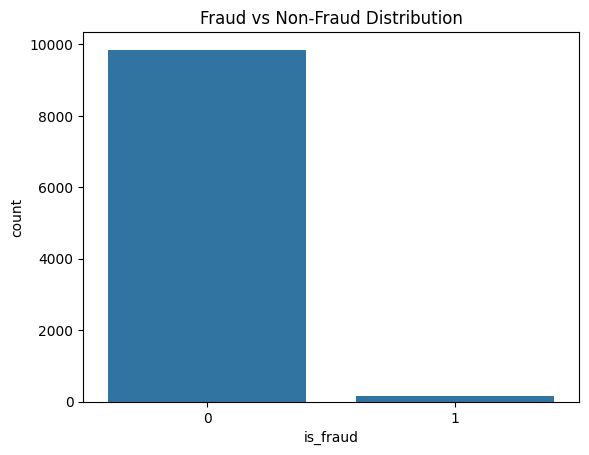

In [6]:
plt.figure()
sns.countplot(x="is_fraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


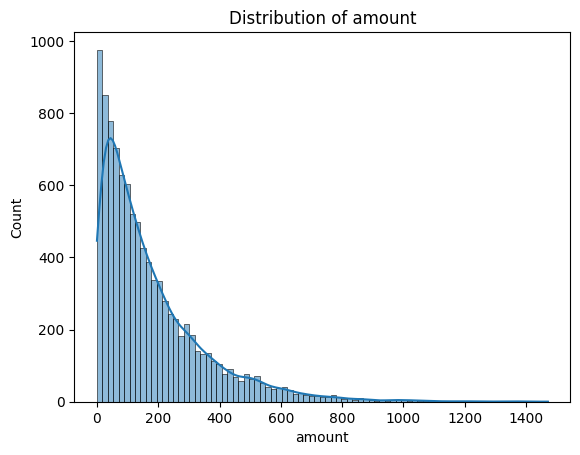

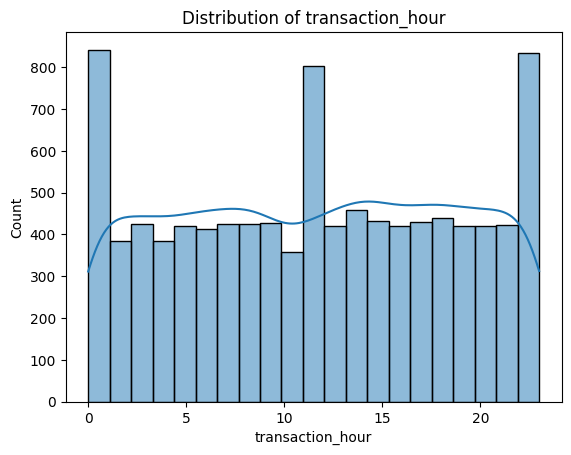

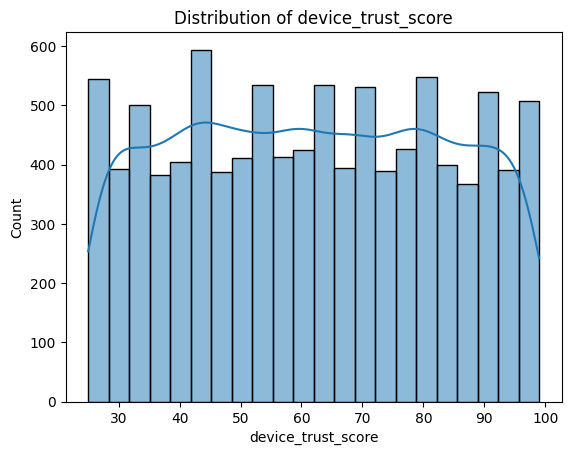

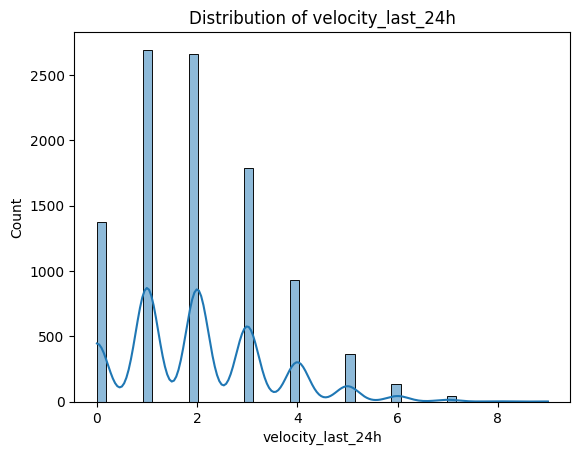

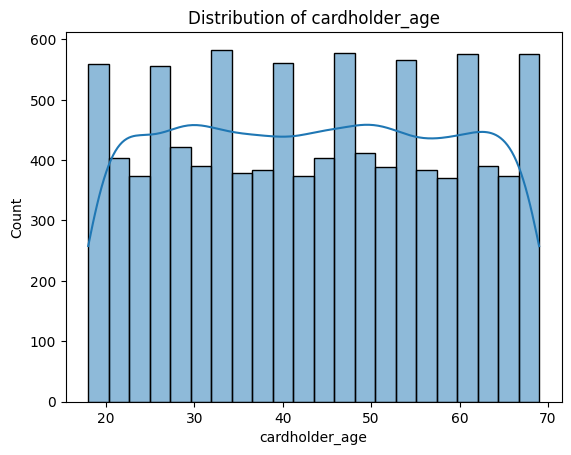

In [7]:
num_cols = [
    "amount", "transaction_hour", "device_trust_score",
    "velocity_last_24h", "cardholder_age"
]

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [8]:
# Night transaction flag
df["night_transaction"] = df["transaction_hour"].isin([0,1,2,3]).astype(int)

# High amount flag
df["high_amount"] = (df["amount"] > 900).astype(int)


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["merchant_category"] = le.fit_transform(df["merchant_category"])


In [10]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

y_resampled.value_counts()


is_fraud
0    9849
1    9849
Name: count, dtype: int64

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.2, random_state=42
)


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


In [14]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.915736,0.900503,0.930426,0.915220
1,Decision Tree,0.964721,0.950126,0.979232,0.964459
2,Random Forest,0.979949,0.969020,0.990654,0.979718


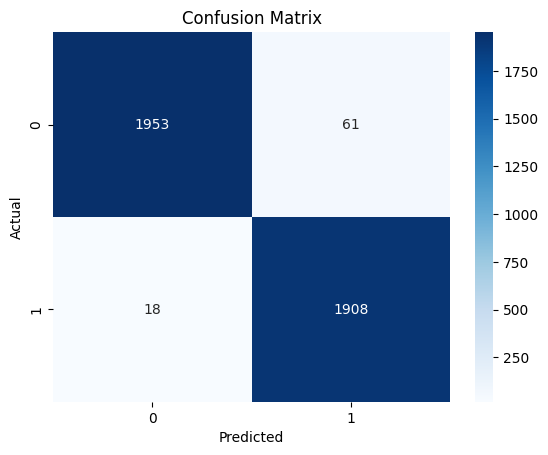

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


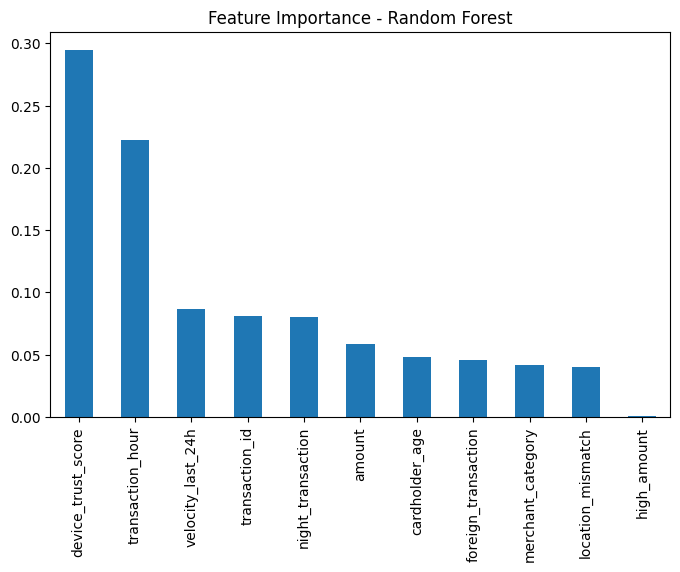

In [16]:
rf = models["Random Forest"]

feature_importance = pd.Series(
    rf.feature_importances_,
    index=df.drop("is_fraud", axis=1).columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.show()


# If you enjoyed this notebook, please consider upvoting 👍 and leaving a comment. Your feedback really motivates me!